# 07 · Recalibração de threshold e agregação do erro (M8 · ADR-0009)

**Fase 2, issue #47.** O erro de uma janela era a **média** (MAE) sobre os 30 passos: um
choque de um único dia entra com peso 1/30 e é *diluído* pelos dias normais, limitando o
**Recall** (ver `report/` §Limitações). Aqui comparamos três agregações temporais do erro ---
`mean` (atual), `max` (pior passo da janela) e `percentile` (p90, meio-termo robusto) --- e
medimos o efeito em Precision/Recall/F1 nos quatro ativos.

**Ponto metodológico crítico (ADR-0009):** `max`/`percentile` mudam toda a distribuição do
erro. O limiar estático p95 foi calibrado sobre a *média*; ele **não transfere**. Para cada
agregação o limiar é **recalculado sobre o mesmo escore** do treino --- sob pena de inflar os
falsos positivos.

Reaproveita a injeção sintética de M5 (choque relativo `k·σ`, ADR-0006) e a normalidade de
treino como referência de `σ`.

## Setup

In [1]:
# --- Colab ---
# !git clone https://github.com/Cerne17/NeuraTrade.git
# %cd NeuraTrade
# !pip install -e .

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, train as T, detect as D
from src.evaluate import inject_price_shocks, labels_to_window_labels, compute_metrics
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG['tickers']
W = CONFIG['preprocessing']['window_size']

# Agregações comparadas (ADR-0009). percentile usa o p configurado.
P = CONFIG['detection'].get('aggregation_percentile', 90)
AGGS = [('mean', None), ('max', None), ('percentile', P)]

pre    = {t: pp.preprocess_ticker(df) for t, df in data.load_all().items()}
models = {t: T.load_model(t) for t in TICKERS}
print('ativos:', TICKERS, '| janela:', W, '| percentil:', P)

ativos: ['PETR4.SA', 'VALE3.SA', 'AMER3.SA', 'ITUB4.SA'] | janela: 30 | percentil: 90


## 1. O limiar não transfere entre agregações

Para cada ativo e cada agregação, recalculamos o erro de **treino** e o limiar estático p95
sobre aquele escore. A tabela mostra que os limiares de `max`/`percentile` são muito maiores
que o de `mean` --- reusar o p95 da média marcaria quase tudo como anomalia.

In [2]:
thr_static = {}   # (ticker, agg) -> limiar estatico recalibrado
err_train  = {}
for t in TICKERS:
    for agg, pct in AGGS:
        e_tr = D.reconstruction_error(models[t], pre[t]['X_train'], aggregation=agg, percentile=pct)
        err_train[(t, agg)] = e_tr
        thr_static[(t, agg)] = D.static_threshold(e_tr)

thr_tbl = pd.DataFrame(
    {agg: [thr_static[(t, agg)] for t in TICKERS] for agg, _ in AGGS},
    index=TICKERS,
)
thr_tbl.index.name = 'ticker'
print('Limiar estatico p95 por agregacao (recalibrado sobre o erro de treino):')
thr_tbl.round(5)

Limiar estatico p95 por agregacao (recalibrado sobre o erro de treino):


,mean,max,percentile
ticker,,,
PETR4.SA,0.12415,0.40772,0.24105
VALE3.SA,0.08215,0.26310,0.16769
AMER3.SA,0.07693,0.28440,0.14997
ITUB4.SA,0.08839,0.37819,0.18578


## 2. Injeção sintética (choque de 1 dia) e avaliação

Mesma estratégia de M5: `n_injections` choques de magnitude `k·σ` em posições aleatórias da
série de teste escalada, com `σ` = desvio-padrão da **normalidade** (retornos de treino
escalados). Cada agregação é avaliada com seu **próprio** limiar recalibrado (estático e
dinâmico).

In [3]:
def test_series_1d(t):
    df = data.load_ticker(t)
    r = pp.log_returns(df)
    r_train, r_test = pp.temporal_split(r)
    scaler = pp.fit_scaler(r_train)
    sigma_norm = float(np.std(pp.apply_scaler(scaler, r_train)))  # sigma da normalidade
    return pp.apply_scaler(scaler, r_test), sigma_norm

rows = []
detail = {}
for t in TICKERS:
    ts, sigma_norm = test_series_1d(t)
    perturbed, labels, positions = inject_price_shocks(ts, sigma=sigma_norm)
    X_pert = pp.make_windows(perturbed)
    wl = labels_to_window_labels(labels)
    for agg, pct in AGGS:
        ep = D.reconstruction_error(models[t], X_pert, aggregation=agg, percentile=pct)
        thr_s = thr_static[(t, agg)]                 # estatico recalibrado (treino)
        thr_d = D.dynamic_threshold(ep)              # dinamico sobre o mesmo escore
        for name, thr in [('estatico', thr_s), ('dinamico', thr_d)]:
            m = compute_metrics(D.flag_anomalies(ep, thr), wl)
            rows.append({'ticker': t, 'agregacao': agg, 'threshold': name,
                         **{k: round(v, 3) for k, v in m.items()}})
        detail[(t, agg)] = dict(ep=ep, wl=wl, thr_s=thr_s)

metrics = pd.DataFrame(rows).set_index(['ticker', 'agregacao', 'threshold']).sort_index()
metrics

precision  recall     f1
ticker   agregacao  threshold                          
AMER3.SA max        dinamico       0.703   0.120  0.205
                    estatico       0.847   0.559  0.674
         mean       dinamico       0.705   0.140  0.234
                    estatico       0.763   0.429  0.549
         percentile dinamico       0.644   0.098  0.170
                    estatico       0.794   0.532  0.637
ITUB4.SA max        dinamico       0.975   0.132  0.233
                    estatico       0.821   0.174  0.287
         mean       dinamico       1.000   0.017  0.034
                    estatico       0.826   0.185  0.303
         percentile dinamico       1.000   0.063  0.119
                    estatico       0.814   0.191  0.309
PETR4.SA max        dinamico       1.000   0.059  0.111
                    estatico       0.768   0.133  0.227
         mean       dinamico       0.844   0.031  0.060
                    estatico       0.205   0.009  0.018
         percentile dinamico       1.000   0.066  0.123
                    estatico       0.605   0.056  0.103
VALE3.SA max        dinamico       1.000   0.061  0.115
                    estatico       0.934   0.537  0.682
         mean       dinamico       1.000   0.074  0.137
                    estatico       0.396   0.024  0.046
         percentile dinamico       1.000   0.084  0.155
                    estatico       0.613   0.056  0.103

## 3. Recall médio por agregação (limiar estático)

Media dos 4 ativos (limiar estatico recalibrado):
            precision  recall     f1
agregacao                           
mean            0.548   0.162  0.229
max             0.842   0.351  0.468
percentile      0.706   0.209  0.288


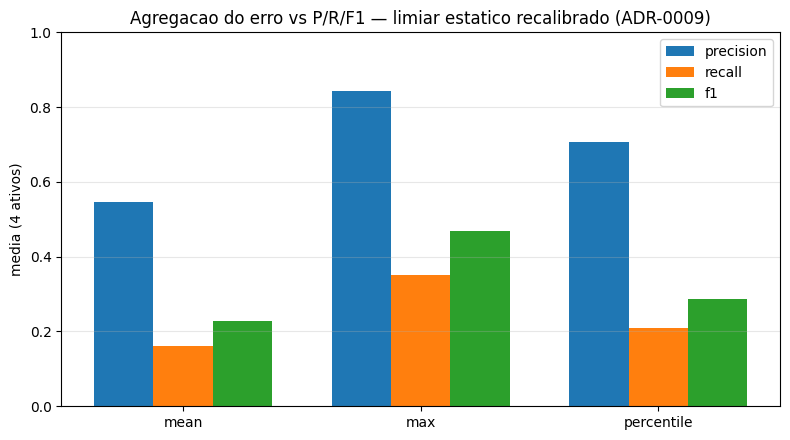

In [4]:
rec = (metrics.xs('estatico', level='threshold')['recall']
       .groupby('agregacao').mean().reindex([a for a, _ in AGGS]))
prec = (metrics.xs('estatico', level='threshold')['precision']
        .groupby('agregacao').mean().reindex([a for a, _ in AGGS]))
f1 = (metrics.xs('estatico', level='threshold')['f1']
      .groupby('agregacao').mean().reindex([a for a, _ in AGGS]))

resumo = pd.DataFrame({'precision': prec, 'recall': rec, 'f1': f1})
print('Media dos 4 ativos (limiar estatico recalibrado):')
print(resumo.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(resumo))
ax.bar(x - 0.25, resumo['precision'], 0.25, label='precision')
ax.bar(x,        resumo['recall'],    0.25, label='recall')
ax.bar(x + 0.25, resumo['f1'],        0.25, label='f1')
ax.set_xticks(x); ax.set_xticklabels(resumo.index)
ax.set_ylabel('media (4 ativos)'); ax.set_ylim(0, 1)
ax.set_title('Agregacao do erro vs P/R/F1 — limiar estatico recalibrado (ADR-0009)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
save_fig(fig, 'm8_agregacao_prf')
plt.show()

## Conclusões

- **O limiar não transfere (Seção 1):** os limiares estáticos de `max`/`percentile` são
  ordens de grandeza maiores que o de `mean`. Reaproveitar o p95 da média sob `max` marcaria
  quase todas as janelas --- por isso a recalibração é obrigatória (ADR-0009).
- **Trade-off Recall × Precision (Seções 2–3):** `max`/`percentile` recuperam o choque de um
  dia que a média diluía, elevando o **Recall**; em troca, a maior sensibilidade ao pior passo
  pode reduzir a **Precision**. O `percentile` (p90) é o meio-termo, menos refém de um único
  ponto ruidoso que o `max`.
- **Leitura por ativo:** AMER3 tem erro de base elevado pós-fraude (anomalias reais competindo
  com o choque sintético) --- ver a tabela da Seção 2 por ativo.
- **Próximos passos (M8):** validação Walk-Forward (`src/validation.py`, ADR-0010) para a
  seleção de `latent_dim`, e transição multivariada OHLCV (`preprocess_ticker_multivariate`,
  ADR-0011) para habilitar anomalias de volume.